# Importaciones y declaraciones de librerias:

ㅤㅤㅤㅤㅤㅤ

In [54]:
#Ciencia de Datos:
import pandas as pd
import seaborn as sns
import numpy as np

# Desarrollo de la Actividad:

ㅤㅤㅤㅤㅤㅤ

In [55]:
#Nuestro dataset lo convertimos en un dataframe
df = pd.read_csv("dataset.csv")
#Eliminamos los datos nulos los cuales son muy pocos (33 de 1039 aprox) y así poder crear nuestro modelo
df = df.dropna()
#No hubo mucho más que limpiar, ya que todo el resto estaba normalizado 

ㅤㅤㅤㅤㅤㅤ

ㅤㅤㅤㅤㅤㅤ

# Creación de los Gráficos: 

ㅤㅤㅤㅤㅤㅤ

# Seaborn.


Hay una casa construida en el año 2024 que sale $2.071.401,84, DOS MILLONES                               
No lo quito porque es un precio realista, puede ser una mansión y yá

In [56]:
df_seaborn = pd.read_csv("dataset.csv")
#Mostramos los valores y yá
df_seaborn.head()
#En caso de querer eliminar un dato Atípico simplemente descomentariamos estas 2 lineas:
# Casa_Cara = df_seaborn["Price"].idxmax()
# df_seaborn = df_seaborn.drop(Casa_Cara,axis=0)

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


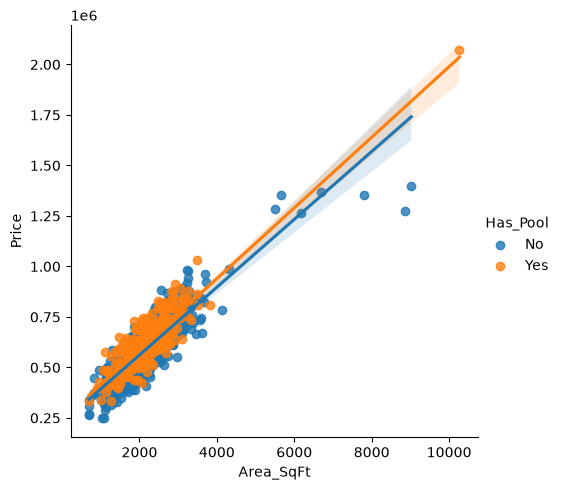

In [57]:
#Mostramos el Gráfico como regresión lineal
sns.lmplot(
    #De donde sacamos los datos
    data=df_seaborn, 
    #Cual va a ser la variable independiente
    x="Area_SqFt",
    #Cual va a ser la variable dndependiente
    y="Price",
    #Diferenciamos si tiene piscina o no
    hue="Has_Pool"
)

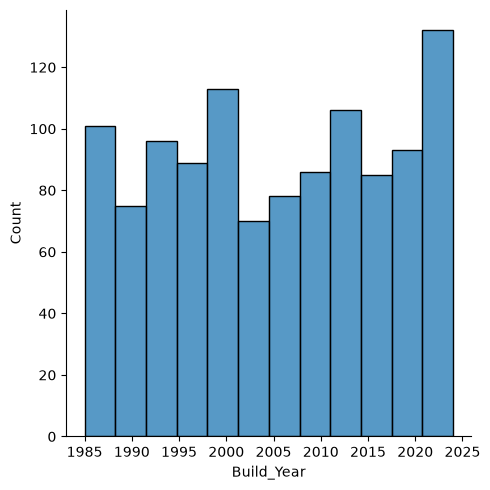

In [58]:
#Graficamos en columnas
sns.displot(
    data=df_seaborn,
    #Vamos a ver cuando fueron creadas mas casas
    x="Build_Year",
)

ㅤㅤㅤㅤㅤㅤ

# Machine Learning:

ㅤㅤㅤㅤㅤㅤ

# Linear and Metrics

In [59]:
#Modelos de Machine Learning:

#Funcion para entrenar y predecir el modelo
from sklearn.linear_model import LinearRegression
#Las metricas para saber la precisión, error cuadratico medio y error cuadratico
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error

#sklearn.linear_model: Sirve para entrenar y predecir
#sklearn.metrics: Nos dice las estadisticas que sacamos

ㅤㅤㅤㅤㅤㅤ

In [60]:
#Creamos un diccionario para saber que columnas vamos a usar (en este caso todas)
#No es necesario hacerlo pero se me hace mas legible así
columnas_elegidas = [
    'Area_SqFt',
    'Rooms', 
    'Build_Year',
    'Location',
    'Street_Type',
    'Furnishing', 
    'Property_Type', 
    'Has_Pool', 
    ]

#Definimos X(cualidades) como todas las columnas para prececir Y(Precio)
X = df[columnas_elegidas].copy()
#Declaramos Y(precio) la cual va a ser predecida por X(cualidades)
y = df["Price"]
#A este metodo nos dice los modelos que son objects y string 
categorias_dummies = df.select_dtypes(include=["object", "str"]).columns
categorias_dummies

Index(['Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool'], dtype='str')

In [61]:
#Declaramos modelo_regresion para usar el LinearRegression()
modelo_regresion = LinearRegression()
#modelo_regresion solo lee binarios(True,False) espor eso que hacemos el metodo get_dummies
X = pd.get_dummies(
    X,
    #Remueve el primer nivel para que no dé un error
    drop_first=True
)
modelo_regresion.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 165.36, 18331.79, 1399.72,..., 49687.68,121972.98, 34870.85]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['Area_SqFt','Rooms','Build_Year',...,'Property_Type_Independent House', 'Property_Type_Villa','Has_Pool_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.624e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


Para que un modelo de regresion lineal funcione no pueden haber datos nulos, pero tambien tenemos que saber que tampoco puede leer strings, por ejemplo, el modelo no sabe que es "Has_Pool", es por eso que esa columna se borra y se convierte en 2, "Has_Pool_Yes" y "Has_Pool_No"

In [62]:
X["Has_Pool_Yes"]
# X["Has_Pool_No"] No Existe ya que si ambos dieran false en la misma fila habría error

0       False
1        True
2       False
3        True
4       False
        ...  
1118    False
1119    False
1120    False
1121    False
1123     True
Name: Has_Pool_Yes, Length: 1027, dtype: bool

Aca surge la magia.
En la celda de abajo declaramos la prediccion que sacamos, el valor verdadero, y sus estadisticas

In [63]:
prediccion=modelo_regresion.predict(X)
print(f" Prediccion de X: {prediccion[0]:.0f}")
print(f" Valor De Y: {y[0]:.0f}")
print("")
#
mse= mean_squared_error(y,prediccion)
r2 = r2_score(y,prediccion)
rmse= root_mean_squared_error(y,prediccion)
#
print(f"Puntos al cuadrado x error: {mse:.0f}")
print(f"Coeficiente de Determinación: {r2*100:.0f}%")
print(f"Raiz del error cuadrático(puntos por los que le erró): {rmse:.0f}")

 Prediccion de X: 561406
 Valor De Y: 568486

Puntos al cuadrado x error: 855065401
Coeficiente de Determinación: 96%
Raiz del error cuadrático(puntos por los que le erró): 29242


In [64]:
tabla_coeficiente = pd.DataFrame({
    "Cáracteristicas":X.columns,
    "Dólares":modelo_regresion.coef_
},)
tabla_coeficiente.sort_values(
    #Ordenamos según la columna valores 
    by="Dólares", 
    #Que sea descenciente
    ascending=False,
    #Permite ver que dato implica mas, sin imporar si es negativo o positivo
    key=abs
    )


,Cáracteristicas,Dólares
18,Property_Type_Villa,121972.980359
9,Location_Prayagraj,-89591.593090
6,Location_Kanpur,-87892.781354
4,Location_Indore,-82973.607805
5,Location_Jaipur,-71375.147913
7,Location_Lucknow,-70338.967259
16,Property_Type_Duplex,67280.347823
15,Furnishing_Unfurnished,-51643.386256
17,Property_Type_Independent House,49687.680004
19,Has_Pool_Yes,34870.850680


# Train test spli.

"Profesor, imagínese que a un estudiante le damos una guía de 100 ejercicios resueltos para que estudie para el final.

El modelo viejo es como si en el examen final le tomáramos exactamente esos mismos 100 ejercicios. El alumno saca un 10, pero no sabemos si realmente sabe aplicar las fórmulas o si simplemente se memorizó la guía de memoria.

El modelo nuevo es lo que hicimos nosotros: le dimos 80 ejercicios para que estudie en su casa, y en el examen le tomamos 20 ejercicios totalmente nuevos que siguen la misma lógica. Como nuestro modelo sacó un 96% en esos ejercicios sorpresa, comprobamos empíricamente que aprendió a resolver el problema real y está listo para producción."

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
model_new = LinearRegression()

In [85]:
#Declaración de variables nuevas
X_new = X.copy()
y_new = df["Price"].copy()
#Entrenamiento del modelo
x_train, x_test, y_train, y_test = train_test_split(X_new,y_new,test_size=0.2,random_state=18)

In [86]:
model_new.fit(x_train,y_train)
model_new.predict(x_test)[0]
precision = model_new.score(x_test,y_test)
print(f"Precision: %{precision*100:.0f}")

Precision: %97


Sacó buena precisión igual, pero la diferencia es que este modelo solo era experto con ESE ÚNICO EXCEL.
El nuevo modelo APRENDIÓ LAS FORMULAS, y si le pasamos otro excel va a saber calcular el precio de esa casa.

ㅤㅤㅤㅤㅤㅤ

# Deployment: 

Está hecho en el main.py porque FastAPI no puede leer los .ipynb

In [69]:
import joblib

# Exportamos el modelo indicando la ruta de la carpeta que creaste
joblib.dump(modelo_regresion, 'models/modelo_casas.pkl')
print("Modelo Entrenado Creado")

# Exportamos las columnas en la misma carpeta
columnas_modelo = list(X.columns)
joblib.dump(columnas_modelo, 'models/columnas_modelo.pkl')
print("Columnas del Modelo Creadas")

Modelo Entrenado Creado
Columnas del Modelo Creadas
